In [82]:
import pandas as pd

import itertools
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from sklearn.utils import check_array, check_scalar

from lingam import DirectLiNGAM

np.random.seed(0)

class HighDimDirectLiNGAM(DirectLiNGAM):
    
    def __init__(self, max_in_degree=3, degree=4, cut_off_scaling=0.5, **kwargs):
        super().__init__(**kwargs)

        self._max_in_degree = check_scalar(max_in_degree, "max_in_degree", int, min_val=2, include_boundaries="neither")
        self._degree = check_scalar(degree, "degree", int, min_val=1)
    
        self._cut_off_scaling = check_scalar(cut_off_scaling, "cut_off_scaling", (int, float), min_val=0)
    
    def _calc_tau(self, k, pa, ch):
        return abs(np.mean((pa ** (k - 1)) * ch) * np.mean(pa ** 2) - np.mean(pa ** k) * np.mean(pa * ch))
    
    def _calc_tau_multi_c(self, pa, ch, k, cond_sets, an_sets):
        n = self._Y.shape[0]
        ret = np.empty(self._Y.shape[1])
        ret.fill(1e10)
        
        for z in range(len(cond_sets)):
            cond = cond_sets[z]
            # XXX: 元はsolveで方程式を解いている。X = solve(A, B)は A*X = BとなるXを求める。では、X=A^-1 @ Bか。
            # https://arma.sourceforge.net/docs.html#solve
            b = np.linalg.pinv(self._yty[np.ix_(cond, cond)]) @ self._yty[cond, pa]
            resid = (self._Y[:, [pa]] - self._Y[:, cond] @ b.reshape(len(cond), 1)).flatten()

            resid_k_1 = np.power(resid, k - 1)
            resid_var = np.mean(np.power(resid, 2))
            resid_k = np.mean(np.power(resid, k))
            
            for i in range(len(ch)):
                ret[ch[i]] = np.min([
                    ret[ch[i]],
                    abs((1.0 / n ) * np.dot(resid_k_1, self._Y[:, ch[i]]) * resid_var - resid_k * (1.0 / n) * np.dot(resid, self._Y[:, ch[i]]))
                ])
            
            for i in range(an_sets.shape[1]):
                ret[an_sets[z, i]] = np.min([
                    ret[an_sets[z, i]],
                    abs((1.0 / n) * np.dot(resid_k_1.T, self._Y[:, an_sets[z, i]]) * resid_var - resid_k * (1.0 / n) * np.dot(resid.T, self._Y[:, an_sets[z, i]]))
                ])
                
            return ret

    def _get_tau_multi(self, i, j, degree, last_root, condition_set, max_in_degree):
        j = list(set(j) - set([i]))
        p = self._Y.shape[1]
        prune_stat = np.array([1e5 for _ in range(p)])
        
        if last_root is None:
            prune_stat[j] = list(map(lambda j: self._calc_tau(degree, self._Y[:, i], self._Y[:, j]), j))
            #print("first step", i, last_root)
            return prune_stat
        
        size_of_set = min(max_in_degree, len(condition_set))
        
        if len(condition_set - set([last_root])) == 1:
            condition_sub_set = np.array([list(condition_set - set([last_root]))]).reshape(1, 1)
        else:
            condition_sub_set = list(itertools.combinations(list(condition_set - set([last_root])), size_of_set - 1))
            condition_sub_set = np.array([list(e) for e in condition_sub_set])
        
        an_sets = np.array(list(map(lambda x: list(condition_set - set(x)), condition_sub_set)))
        if len(an_sets) == 1 and an_sets.shape[1] > 0:
            an_sets = an_sets.T
        
        if len(condition_sub_set) == 1 and len(condition_sub_set) == 0:
            condition_sub_set = np.array([last_root])
        else:
            condition_sub_set = np.concatenate([np.full(len(condition_sub_set), last_root).reshape(-1, 1), condition_sub_set], axis=1).astype(int)
        
        # XXX: 元コードで1を引くのはゼロ始まりということではないか？set系はベクトルだから全要素から引くのだろう。(condition_sub_setとか実際は1要素のベクトルにしからならないのでは？)
        #print(condition_sub_set, i, last_root)
        prune_stat = self._calc_tau_multi_c(i, j, degree, condition_sub_set, an_sets)
        print("PruneStat", prune_stat)
        return prune_stat
        
    def fit(self, Y):
        self._Y = check_array(Y)
        
        # cov
        self._yty = self._Y.T @ self._Y
        
        cut_off = 0
        
        ordered = []
        p = self._Y.shape[1]
        
        unordered = list(range(p))
        
        prune_stats = np.full((p, p), 1e5)
        np.fill_diagonal(prune_stats, 0)
        
        while len(unordered) > 1:
            print("=============", len(ordered))
            print(prune_stats)
            
            output_cond_set = []
            output_tau_min = []
            for i in unordered:
                print("+", "ordered=", ordered, "filter=", np.argwhere(prune_stats[i] > cut_off).flatten(), "lastRoot=", ordered[-1:])
                cond_set = set.intersection(set(ordered), set(np.argwhere(prune_stats[i] > cut_off).flatten()))
                cond_set = set.union(cond_set, set(ordered[-1:] if len(ordered) > 0 else set()))
                print("condset", cond_set)
            
                last_root = ordered[-1] if len(ordered) > 0 else None
                tau_min = self._get_tau_multi(i, unordered, self._degree, last_root, cond_set, self._max_in_degree)
                
                output_cond_set.append(cond_set)
                output_tau_min.append(tau_min)
            output_tau = np.array(output_tau_min)
            
            prune_stats[unordered, :] = np.min([prune_stats[unordered, :], output_tau], axis=0)
            np.fill_diagonal(prune_stats, 0)
            
            output_tau_stats = np.max(prune_stats[np.ix_(unordered, unordered)], axis=1)
            
            root = unordered[np.argmin(output_tau_stats)]
            
            cut_off = max(cut_off, min(output_tau_stats) * self._cut_off_scaling)
            
            ordered.append(root)
            unordered.remove(root)
        
        self._causal_order = np.array(ordered + unordered)
        return self

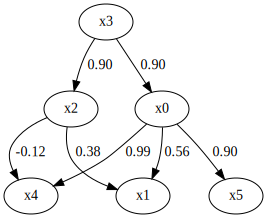

============= 0
[[     0. 100000. 100000. 100000. 100000. 100000.]
 [100000.      0. 100000. 100000. 100000. 100000.]
 [100000. 100000.      0. 100000. 100000. 100000.]
 [100000. 100000. 100000.      0. 100000. 100000.]
 [100000. 100000. 100000. 100000.      0. 100000.]
 [100000. 100000. 100000. 100000. 100000.      0.]]
+ ordered= [] filter= [1 2 3 4 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 2 3 4 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 1 3 4 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 1 2 4 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 1 2 3 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 1 2 3 4] lastRoot= []
condset set()
============= 1
[[0.         0.04580318 0.08145119 0.10648469 0.07166608 0.0322711 ]
 [0.13046885 0.         0.07728439 0.1064336  0.0872871  0.06107976]
 [0.08315745 0.03633419 0.         0.08985892 0.05737715 0.08826526]
 [0.07488984 0.0264916  0.00423243 0.         0.00327959 0.006119  ]
 [0.10349441 0.1444

array([3, 0, 1, 2, 4, 5])

In [83]:
import lingam

np.random.seed(0)

m = np.array([
    [ 0.000,  0.000,  0.000,  0.895,  0.000,  0.000],
    [ 0.565,  0.000,  0.377,  0.000,  0.000,  0.000],
    [ 0.000,  0.000,  0.000,  0.895,  0.000,  0.000],
    [ 0.000,  0.000,  0.000,  0.000,  0.000,  0.000],
    [ 0.991,  0.000, -0.124,  0.000,  0.000,  0.000],
    [ 0.895,  0.000,  0.000,  0.000,  0.000,  0.000]
])

if False:
    m = np.zeros((6, 6))
    for i in range(6 - 1):
        m[i +1, i]  = 1

display(lingam.utils.make_dot(m))

sample_size = 100

error_vars = [0.2, 0.2, 0.2, 1.0, 0.2, 0.2]
params = [0.5 * np.sqrt(12 * v) for v in error_vars]

generate_error = lambda p: np.random.uniform(-p, p, size=sample_size)


e = np.array([generate_error(p) for p in params])

X = np.linalg.pinv(np.eye(len(m)) - m) @ e
X = X.T

pd.DataFrame(X).to_csv("test_data.csv", index=False)

model = HighDimDirectLiNGAM()
ret = model.fit(X)

model.causal_order_

In [74]:
results = []
for i in range(1):
    e = np.array([generate_error(p) for p in params])

    X = np.linalg.pinv(np.eye(len(m)) - m) @ e
    X = X.T

    model = HighDimDirectLiNGAM()
    ret = model.fit(X)

    results.append(model.causal_order_)

print(sorted(list(zip(*np.unique(results, axis=0, return_counts=True))), key=lambda e: e[1], reverse=True))

def is_correct(order):
    if order[0] != 3:
        return False
    
    if set(order[1:3]) != set([0, 2]):
        return False
    
    if set(order[3:]) != set([1, 4, 5]):
        return False
    
    return True

sum([is_correct(r) for r in results])

============= 0
[[     0. 100000. 100000. 100000. 100000. 100000.]
 [100000.      0. 100000. 100000. 100000. 100000.]
 [100000. 100000.      0. 100000. 100000. 100000.]
 [100000. 100000. 100000.      0. 100000. 100000.]
 [100000. 100000. 100000. 100000.      0. 100000.]
 [100000. 100000. 100000. 100000. 100000.      0.]]
+ ordered= [] filter= [1 2 3 4 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 2 3 4 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 1 3 4 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 1 2 4 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 1 2 3 5] lastRoot= []
condset set()
+ ordered= [] filter= [0 1 2 3 4] lastRoot= []
condset set()
============= 1
[[0.         0.00740538 0.15313316 0.17769572 0.04282643 0.01077544]
 [0.06736083 0.         0.17758888 0.20164434 0.05594829 0.00459152]
 [0.11902327 0.10870929 0.         0.13595237 0.12270031 0.06721498]
 [0.00718291 0.03475712 0.00659039 0.         0.02854867 0.01477514]
 [0.03739388 0.0998

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [75]:
np.arange(5) @ np.array([1,2])

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 5)